# NASA Turbofan Engine Data - A Beginner's Guide to EDA & RUL

Welcome! In this notebook, we look at the **NASA Turbofan Engine Degradation Dataset** (specifically a subset called FD001).
If you are new to predictive maintenance, don't worry! We will explain everything step by step.

### What is RUL?
**RUL** stands for **Remaining Useful Life**. It simply means: *"How many more flights (cycles) can this engine make before it breaks down?"*
Predicting when a machine will fail allows us to schedule maintenance right before it happens, saving money and preventing accidents.

### What are the Sensors?
Imagine an airplane engine has 21 different thermometers, pressure gauges, and speedometers attached to it. These are our **sensors**.
As the engine gets old and worn out, some of these sensors will start showing unusual readings (like a running a fever). By looking at these readings, we can guess the engine's health.

### What we will do in this notebook:
1. **Load the Data:** Read the engine health records.
2. **Explore the Data (EDA):** Look at general statistics, check for missing values, and see how the sensors change over time.
3. **Compute RUL:** Calculate the exact Remaining Useful Life for the training data so we can teach a Machine Learning model later.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 4)

BASE_DIR = Path.cwd()  # this notebook should live in NASA_Turbofan folder
DATA_DIR = BASE_DIR.parent / 'data' / 'CMAPSSData'
DATA_DIR

WindowsPath('d:/Javed/MaintAI/data/CMAPSSData')

## 1. Load the Data

We are loading three files:
- `train_df`: This is our training data. It tracks multiple engines from day one until the exact moment they fail.
- `test_df`: This is our test data. It tracks engines for a while, but stops *before* they fail. Our future goal will be to guess when these will fail.
- `rul_df`: The actual true answers for the test data (how many cycles were left).

**What do the columns mean?**
- `engine_id`: The ID number of the engine being tracked.
- `cycle`: The time step. You can think of one cycle as one flight.
- `setting_1` to `setting_3`: The conditions the engine is operating under (like altitude or speed).
- `sensor_1` to `sensor_21`: The readings from the 21 different sensors on the engine.


In [2]:
col_names = (['engine_id', 'cycle'] +
             [f'setting_{i}' for i in range(1, 4)] +
             [f'sensor_{i}' for i in range(1, 22)])

train_path = DATA_DIR / 'train_FD001.txt'
test_path = DATA_DIR / 'test_FD001.txt'
rul_path = DATA_DIR / 'RUL_FD001.txt'

train_df = pd.read_csv(train_path, sep='\s+', header=None, names=col_names)
test_df = pd.read_csv(test_path, sep='\s+', header=None, names=col_names)
rul_df = pd.read_csv(rul_path, sep='\s+', header=None, names=['RUL'])

train_df.head()

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


### Explanation (Loading)
- The training dataset `train_df` is our main focus here because we know the full life story of these engines, right up to failure.
- Let's use it to understand how sensors behave over an engine's lifetime.


## 2. Basic Dataset Overview
Let's see how much data we have and how many flights (cycles) an engine typically survives.


Train shape: (20631, 26)
Test shape: (13096, 26)
First 5 rows of train:


,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


Data types:


engine_id      int64
cycle          int64
setting_1    float64
setting_2    float64
setting_3    float64
sensor_1     float64
sensor_2     float64
sensor_3     float64
sensor_4     float64
sensor_5     float64
sensor_6     float64
sensor_7     float64
sensor_8     float64
sensor_9     float64
sensor_10    float64
sensor_11    float64
sensor_12    float64
sensor_13    float64
sensor_14    float64
sensor_15    float64
sensor_16    float64
sensor_17      int64
sensor_18      int64
sensor_19    float64
sensor_20    float64
sensor_21    float64
dtype: object

Number of engines in train: 100
Cycles per engine (min, max): 128 362


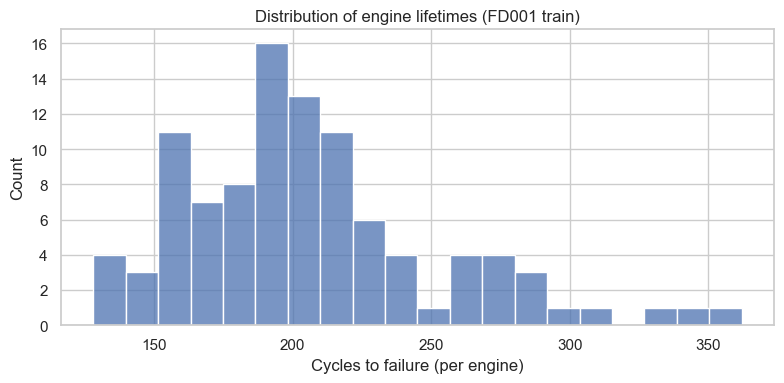

In [3]:
print('Train shape:', train_df.shape)
print('Test shape:', test_df.shape)

print('First 5 rows of train:')
display(train_df.head())

print('Data types:')
display(train_df.dtypes)

n_engines_train = train_df['engine_id'].nunique()
cycles_per_engine = train_df.groupby('engine_id')['cycle'].max()

print('Number of engines in train:', n_engines_train)
print('Cycles per engine (min, max):', cycles_per_engine.min(), cycles_per_engine.max())

plt.figure()
sns.histplot(cycles_per_engine, bins=20, kde=False)
plt.xlabel('Cycles to failure (per engine)')
plt.ylabel('Count')
plt.title('Distribution of engine lifetimes (FD001 train)')
plt.tight_layout()
plt.show()

### Graph: Distribution of Engine Lifetimes
- **X-Axis:** `Max cycle per engine` (The total number of flights/cycles an engine survived before failing).
- **Y-Axis:** `Count` (The number of engines that survived exactly that many flights).

**What it tells us:**
This histogram shows the lifespan of our machines. If you see a tall bar around 200, it means the majority of engines break down at around 200 flights. 

**What to look for if you plot this yourself:**
Look at where the "bulk" of the data sits. This tells you the average life expectancy. Look at the edges to see the earliest failures and the longest survivors.


## 3. Check for Missing Values
In real-world data, sensors sometimes fail or stop recording. Let's see if we have any "blank" or missing readings.


In [4]:
missing_counts = train_df.isna().sum()
missing_counts

engine_id    0
cycle        0
setting_1    0
setting_2    0
setting_3    0
sensor_1     0
sensor_2     0
sensor_3     0
sensor_4     0
sensor_5     0
sensor_6     0
sensor_7     0
sensor_8     0
sensor_9     0
sensor_10    0
sensor_11    0
sensor_12    0
sensor_13    0
sensor_14    0
sensor_15    0
sensor_16    0
sensor_17    0
sensor_18    0
sensor_19    0
sensor_20    0
sensor_21    0
dtype: int64

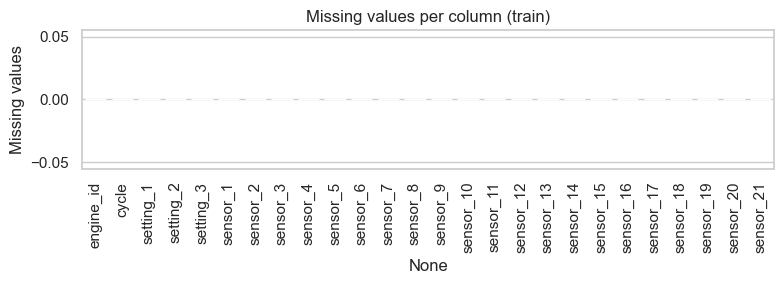

In [5]:
plt.figure(figsize=(8, 3))
sns.barplot(x=missing_counts.index, y=missing_counts.values)
plt.xticks(rotation=90)
plt.ylabel('Amount of Missing Data')
plt.title('Missing Sensor Readings (We have zero missing data!)')
plt.tight_layout()
plt.show()
print('Look! Every column has 0 missing values.')

## 4. Statistical Summary of Sensors
Let's look at the average (mean) and spread (standard deviation) of the sensor readings.
If a sensor never changes its value (standard deviation is 0), it won't help us predict failure because it's completely ignoring the engine's health!


## 4. Statistical summary of features
We now look at basic statistics (mean, std, min, max) for the features, especially the sensors.

In [6]:
display(train_df.describe())

sensor_cols = [c for c in train_df.columns if c.startswith('sensor_')]
display(train_df[sensor_cols].describe().T)

,engine_id,cycle,setting_1,setting_2,setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,20631.000000,20631.000000,20631.000000,20631.000000,20631.0,20631.00,20631.000000,20631.000000,20631.000000,2.063100e+04,...,20631.000000,20631.000000,20631.000000,20631.000000,2.063100e+04,20631.000000,20631.0,20631.0,20631.000000,20631.000000
mean,51.506568,108.807862,-0.000009,0.000002,100.0,518.67,642.680934,1590.523119,1408.933782,1.462000e+01,...,521.413470,2388.096152,8143.752722,8.442146,3.000000e-02,393.210654,2388.0,100.0,38.816271,23.289705
std,29.227633,68.880990,0.002187,0.000293,0.0,0.00,0.500053,6.131150,9.000605,1.776400e-15,...,0.737553,0.071919,19.076176,0.037505,1.387812e-17,1.548763,0.0,0.0,0.180746,0.108251
min,1.000000,1.000000,-0.008700,-0.000600,100.0,518.67,641.210000,1571.040000,1382.250000,1.462000e+01,...,518.690000,2387.880000,8099.940000,8.324900,3.000000e-02,388.000000,2388.0,100.0,38.140000,22.894200
25%,26.000000,52.000000,-0.001500,-0.000200,100.0,518.67,642.325000,1586.260000,1402.360000,1.462000e+01,...,520.960000,2388.040000,8133.245000,8.414900,3.000000e-02,392.000000,2388.0,100.0,38.700000,23.221800
50%,52.000000,104.000000,0.000000,0.000000,100.0,518.67,642.640000,1590.100000,1408.040000,1.462000e+01,...,521.480000,2388.090000,8140.540000,8.438900,3.000000e-02,393.000000,2388.0,100.0,38.830000,23.297900
75%,77.000000,156.000000,0.001500,0.000300,100.0,518.67,643.000000,1594.380000,1414.555000,1.462000e+01,...,521.950000,2388.140000,8148.310000,8.465600,3.000000e-02,394.000000,2388.0,100.0,38.950000,23.366800
max,100.000000,362.000000,0.008700,0.000600,100.0,518.67,644.530000,1616.910000,1441.490000,1.462000e+01,...,523.380000,2388.560000,8293.720000,8.584800,3.000000e-02,400.000000,2388.0,100.0,39.430000,23.618400


,count,mean,std,min,25%,50%,75%,max
sensor_1,20631.0,518.670000,0.000000e+00,518.6700,518.6700,518.6700,518.6700,518.6700
sensor_2,20631.0,642.680934,5.000533e-01,641.2100,642.3250,642.6400,643.0000,644.5300
sensor_3,20631.0,1590.523119,6.131150e+00,1571.0400,1586.2600,1590.1000,1594.3800,1616.9100
sensor_4,20631.0,1408.933782,9.000605e+00,1382.2500,1402.3600,1408.0400,1414.5550,1441.4900
sensor_5,20631.0,14.620000,1.776400e-15,14.6200,14.6200,14.6200,14.6200,14.6200
sensor_6,20631.0,21.609803,1.388985e-03,21.6000,21.6100,21.6100,21.6100,21.6100
sensor_7,20631.0,553.367711,8.850923e-01,549.8500,552.8100,553.4400,554.0100,556.0600
sensor_8,20631.0,2388.096652,7.098548e-02,2387.9000,2388.0500,2388.0900,2388.1400,2388.5600
sensor_9,20631.0,9065.242941,2.208288e+01,9021.7300,9053.1000,9060.6600,9069.4200,9244.5900
sensor_10,20631.0,1.300000,0.000000e+00,1.3000,1.3000,1.3000,1.3000,1.3000


## 5. How are the Sensor Values Distributed?
Let's look at histograms for a few interesting sensors. A histogram shows us what range of values a sensor usually outputs.


## 5. Distribution of key sensor values
We plot histograms for a few key sensors to see how their values are distributed.

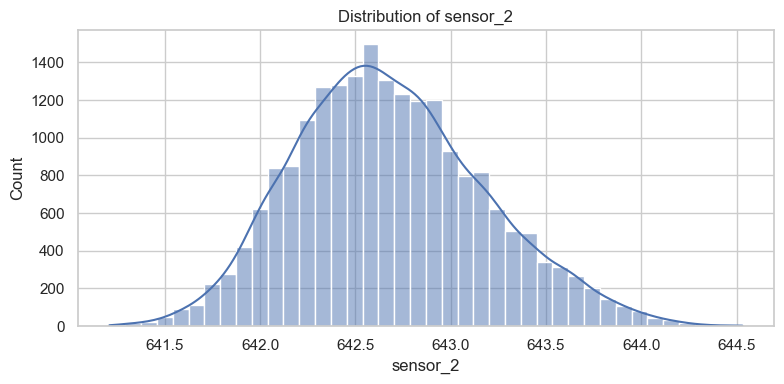

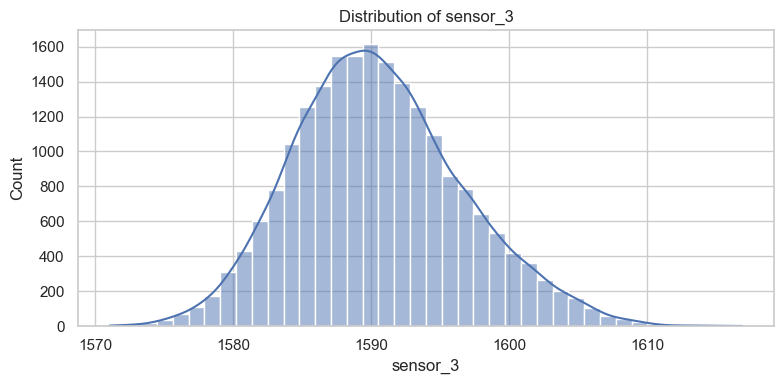

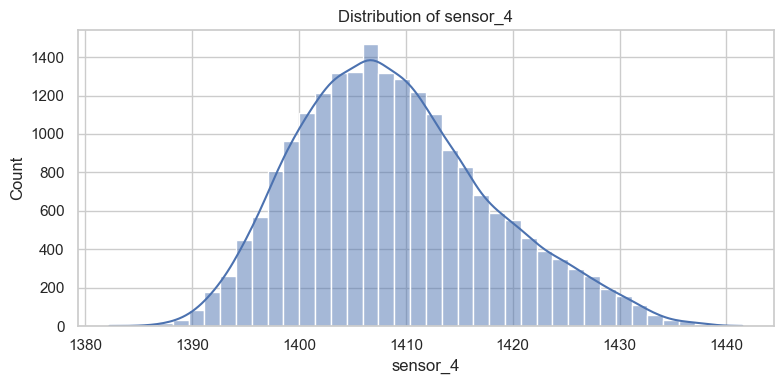

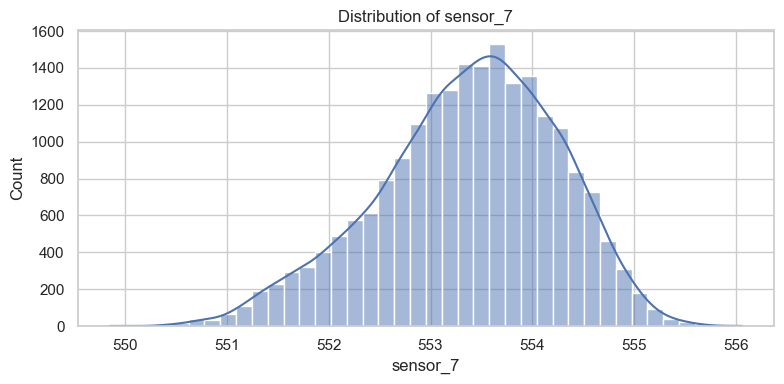

In [7]:
key_sensors = ['sensor_2', 'sensor_3', 'sensor_4', 'sensor_7']  # you can change this list

for s in key_sensors:
    plt.figure()
    sns.histplot(train_df[s], bins=40, kde=True)
    plt.title(f'Distribution of {s}')
    plt.xlabel(s)
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

## 6. Correlation Analysis
A **correlation heatmap** shows us how sensors relate to each other and to the engine's life (the `cycle` column).
- A correlation near **1.0 (dark red)** means the values move up together.
- A correlation near **-1.0 (dark blue)** means as one goes up, the other goes down.
- A correlation near **0** means they don't affect each other.


## 6. Correlation analysis (heatmap)
We compute correlations between all sensor features and visualize them in a heatmap.

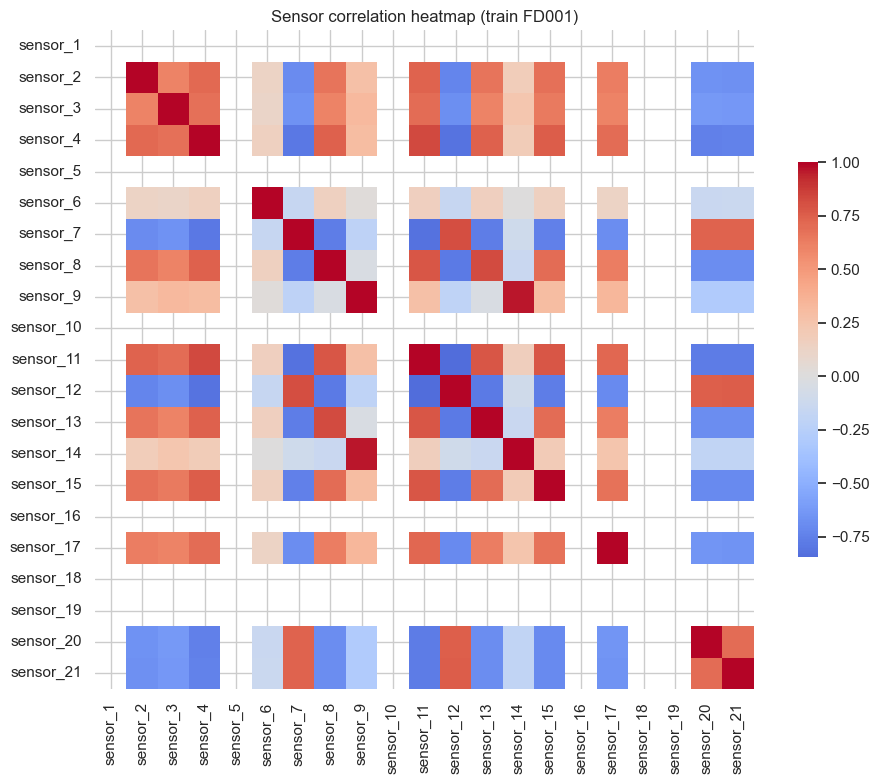

In [8]:
corr = train_df[sensor_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.6})
plt.title('Sensor correlation heatmap (train FD001)')
plt.tight_layout()
plt.show()

## 7. Sensor Trends Over Time (Engine Degradation)
Let's visualize the actual "fever" of an engine. We will plot the readings of a few helpful sensors for **Engine 1** over its entire lifetime.


## 7. Trends of sensors over cycles for a few engines
We now look at how some sensors evolve over **time (cycles)** for a handful of engines. This shows degradation patterns.

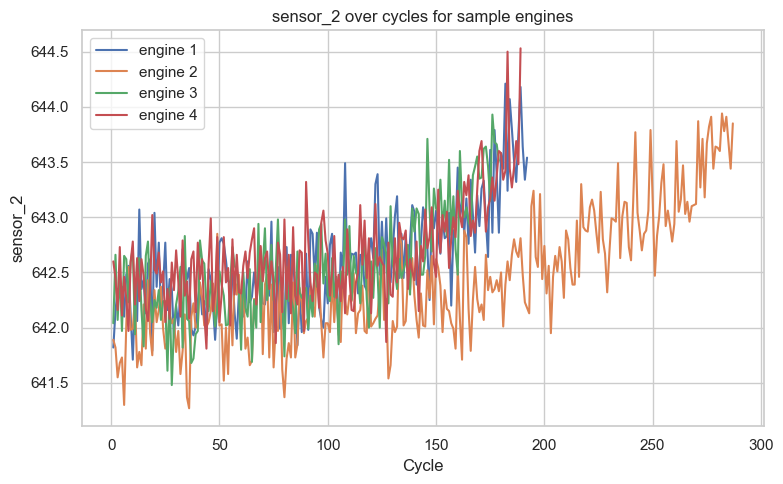

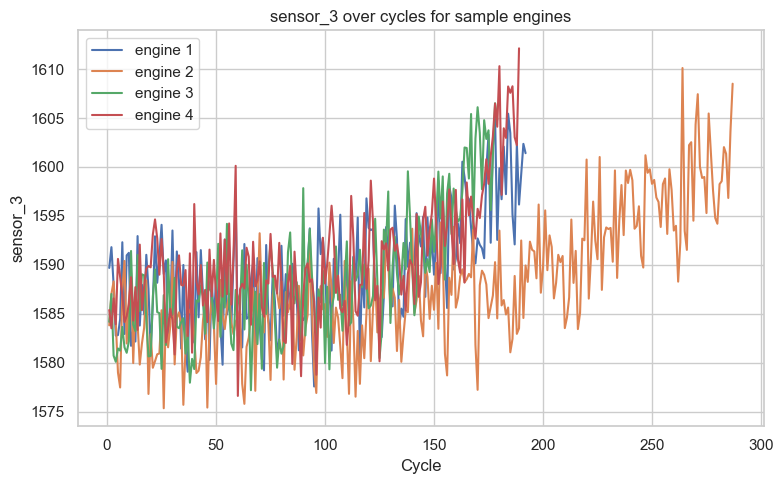

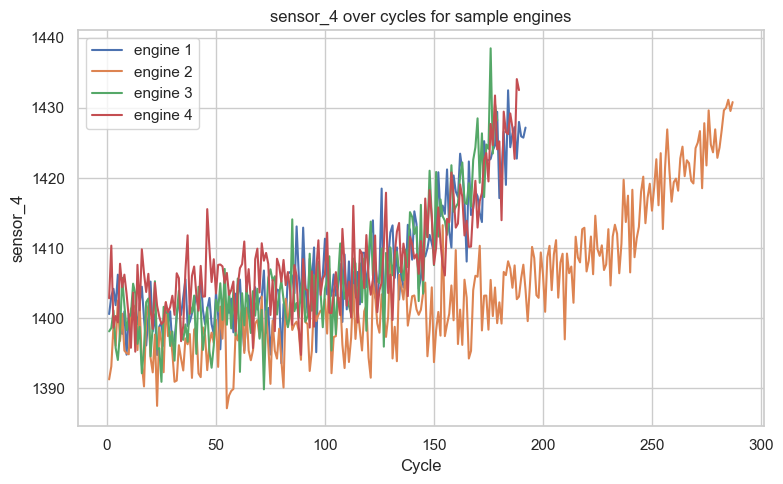

In [9]:
sample_engines = train_df['engine_id'].unique()[:4]  # first 4 engines
trend_sensors = ['sensor_2', 'sensor_3', 'sensor_4']  # adjust as needed

for s in trend_sensors:
    plt.figure(figsize=(8, 5))
    for eid in sample_engines:
        sub = train_df[train_df['engine_id'] == eid].sort_values('cycle')
        plt.plot(sub['cycle'], sub[s], label=f'engine {eid}')
    plt.title(f'{s} over cycles for sample engines')
    plt.xlabel('Cycle')
    plt.ylabel(s)
    plt.legend()
    plt.tight_layout()
    plt.show()

## 8. Compute Remaining Useful Life (RUL)
Since we know exactly when each engine in the training set failed, we can walk backward from the failure day and calculate the exact **RUL** for every single flight.

- For example, if an engine failed on Flight 192:
  - On Flight 1, the RUL was 191.
  - On Flight 2, the RUL was 190.
  - On Flight 191, the RUL was 1.

We also create a **Capped RUL**. Why? Because predicting whether an engine has 300 vs 200 flights left is usually unpredictable and mathematically unnecessary (it's completely healthy either way). By capping the RUL at 125, we force the model to only care about the danger zone (the last 125 flights).


## 8. Create RUL labels for the training data
In the original CMAPSS training data, there is **no explicit RUL column** per time step.
However, each training engine is run **until failure**, so we can compute RUL ourselves.

For an engine with last cycle $T$ and a given cycle $t$, the Remaining Useful Life is:

$$ RUL = T - t $$

We will:
- Add a new column `RUL` to `train_df`.\n
- Also add a capped version `RUL_capped` (e.g., cap at 125 cycles) which is commonly used to limit very large RUL values.

In [10]:
# Compute max cycle per engine and derive RUL per row
max_cycle_per_engine = train_df.groupby('engine_id')['cycle'].transform('max')
train_df['RUL'] = max_cycle_per_engine - train_df['cycle']

# Optional: cap RUL to reduce range (helps training some models)
RUL_CAP = 125
train_df['RUL_capped'] = train_df['RUL'].clip(upper=RUL_CAP)

train_df[['engine_id', 'cycle', 'RUL', 'RUL_capped']].head()

,engine_id,cycle,RUL,RUL_capped
0,1,1,191,125
1,1,2,190,125
2,1,3,189,125
3,1,4,188,125
4,1,5,187,125


### 9. Distribution of RUL (labels we just created)
We now plot how RUL is distributed across all time steps in the training data.

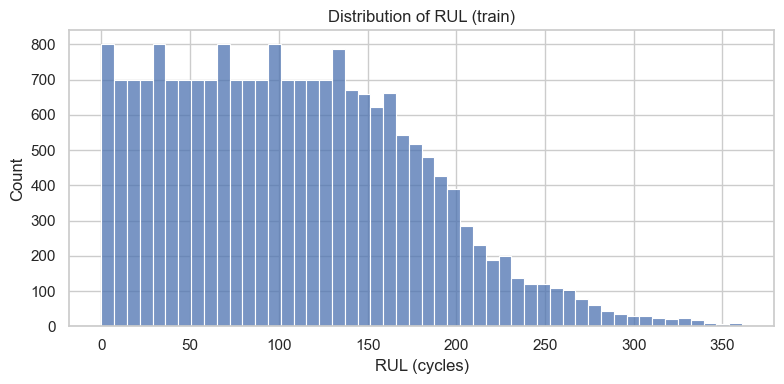

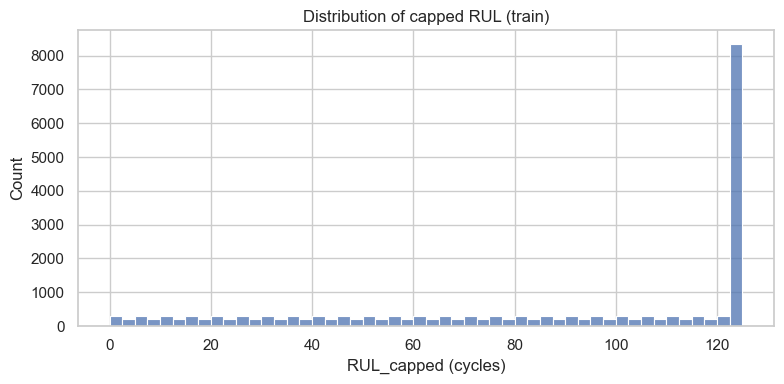

In [11]:
plt.figure()
sns.histplot(train_df['RUL'], bins=50, kde=False)
plt.title('Actual RUL across all flights')
plt.xlabel('RUL (cycles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

plt.figure()
sns.histplot(train_df['RUL_capped'], bins=50, kde=False)
plt.title('Capped RUL (We only focus on the last 125 flights)')
plt.xlabel('RUL_capped (cycles)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### Insight (RUL distribution)
- Many rows will have **small RUL** values (near failure), especially towards the end of each engine's life.\n
- Rows at the beginning of an engine's life have **large RUL**.\n
- Capping RUL reduces the effect of very large values and makes the target more balanced for learning, which is a common trick in CMAPSS-based RUL modeling.\n

Now your training data train_df **has labels** (`RUL` and `RUL_capped`) and is ready for building RUL prediction models (e.g., LSTM/GRU).